# Grid FOV finder - biology demo (ERK-KTR)

A sibling of `grid_fov_finder_demo.ipynb`. That notebook picks FOVs purely on
**geometric density** (cell count + nearest-neighbour clumping). This one adds
the **biology side**: an ERK-KTR *readiness* gate on top of density, so the
finder selects fields that are both a good, not-clumped layer **and** mostly in
a usable ERK state.

Two orthogonal selectors, evaluated per candidate FOV window:

| selector | what | how | comes from |
|---|---|---|---|
| **density** | enough, not-clumped cells | geometric, from the centroid cloud | `min_cells` / `clump_distance_um` / `min_nn_um` ... |
| **biology** | cells in a usable ERK state | per-cell CNR, gated by an `FOVCondition` | `FE_ErkKtr` + `fov_conditions` |

**Precedence** (see `faro.agents.fov_density.FovDensityScorer`):
- *Validity* is a hard **AND** - a window must pass density **and** every
  `FOVCondition`; neither overrides the other.
- *Ranking* among valid windows is **density only** (`n_cells * (1 -
  clumped_fraction)`); CNR is a gate, not a tie-breaker.
- *Fallback*: with `strict_count=True`, if too few windows pass, padding picks
  the best-density leftovers **regardless** of why they failed (so a padded FOV
  can be clumped or not-ERK-ready). Use `strict_count=False` to return fewer
  FOVs instead of padding.

> Note: clumping is handled geometrically here, so you do NOT add a
> `SpatialFE`/`nn_dist` condition. `fov_conditions` are for biology the geometry
> can't see (CNR). Tune the density numbers offline in
> `grid_density_fov_finder_tuning.ipynb`.

## 1. Microscope + channels

The ERK gate needs the reporter channel: `FE_ErkKtr` reads **imaging channel
index 1**. So image two channels - nuclear marker (segmented) at index 0 and the
ERK-KTR reporter at index 1.

In [1]:
from faro.microscope.pertzlab.jungfrau import Jungfrau
from faro.core.data_structures import PowerChannel

mic = Jungfrau()
mic.mmc.setChannelGroup("TTL_ERK")
mic.mmc.setProperty("TIPFSStatus", "State", "On")  # PFS holds focus

imaging_channels = (
    PowerChannel(
        config="miRFP", exposure=125, group="TTL_ERK", power=95
    ),  # ch0: nuclear (segmented)
    PowerChannel(
        config="mScarlet3", exposure=150, group="TTL_ERK", power=95
    ),  # ch1: ERK-KTR reporter (FE_ErkKtr)
)

## 2. Segmentator + ERK feature extractor + readiness gate

`FE_ErkKtr("labels")` builds a cytosolic ring around each nucleus and reports
per-cell `cnr` (cytosolic/nuclear ratio). The gate accepts a window only where
the ERK signal is usable - here **CNR below 1.0 in at least 70% of its cells**
(low baseline ERK = ready to be stimulated), exactly the v1 readiness rule.

In [2]:
from faro.segmentation.cellpose_v4 import CellposeV4
from faro.feature_extraction.erk_ktr import FE_ErkKtr
from faro.agents import FOVCondition

segmentator = CellposeV4()
erk_fe = FE_ErkKtr("labels")  # per-cell CNR (uses imaging ch 1)
ready = FOVCondition("cnr", "below", 1.0, min_fraction=0.7)  # ERK readiness gate

## 3. (Optional) napari viewer for live focus

In [3]:
from napari_micromanager import MainWindow
import napari

viewer = napari.Viewer()
mm_wdg = MainWindow(viewer, mmcore=mic.mmc)
viewer.window.add_dock_widget(mm_wdg)

## 4. Configure and run the grid finder WITH the ERK gate

Same finder as the density demo, plus two args: `feature_extractor=erk_fe` and
`fov_conditions=[ready]`. Every grid tile is segmented (density) **and** run
through the extractor (CNR); the per-cell CNR is joined onto the centroid cloud
by label, and each candidate window is kept only if it passes density **and**
the ERK gate. `store_tiles=True` keeps the tiles for the montage in section 8.

[GridFOVFinderAgent] Phase 0: 5x5 grid scan in 1 well(s): ['C7'] (fov=666x666 µm, px=0.650)
[GridFOVFinderAgent] well C7: 619 cells in scan, 2 passing window(s), selected 3.


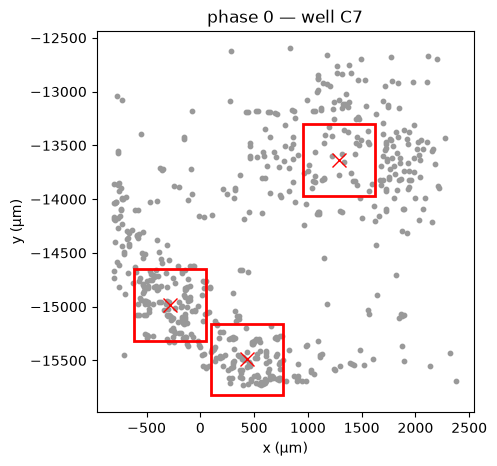

[GridFOVFinderAgent] Phase 0 — selected FOVs:
    C7_0000: 35 cells, clumped=0.00, med_nn=43.5µm
    C7_0001: 127 cells, clumped=0.09, med_nn=19.5µm (padded: above_max_cells)
    C7_0002: 112 cells, clumped=0.08, med_nn=17.9µm (padded: above_max_cells)


[FovPosition(x=1290.8067143278847, y=-13637.19075382423, z=None, name='C7_0000'),
 FovPosition(x=-283.54286888392056, y=-14983.807384271344, z=None, name='C7_0001'),
 FovPosition(x=433.9626960391851, y=-15489.632056554565, z=None, name='C7_0002')]

In [7]:
from faro.agents import GridFOVFinderAgent

finder = GridFOVFinderAgent(
    microscope=mic,
    well_plate_plan="./calib_plate_96.json",
    wells=["C7"],
    fovs_per_well=3,
    grid_rows=5,
    grid_cols=5,
    grid_overlap=0.05,
    # --- geometric density band (tune in grid_density_fov_finder_tuning.ipynb) ---
    min_cells=35,
    max_cells=100,
    clump_distance_um=10.0,
    max_clumped_fraction=0.05,
    recenter=True,
    # --- biology: ERK readiness gate ---
    feature_extractor=erk_fe,  # per-cell CNR
    fov_conditions=[ready],  # keep only ERK-ready windows
    # --- acquisition / geometry ---
    imaging_channels=imaging_channels,
    segmentator=segmentator,
    seg_channel_index=0,  # segment the nuclear channel
    z=None,  # PFS holds focus
    flip_x=False,
    flip_y=True,  # camera->stage flips (~180 deg plate rotation)
    pixel_size_um=0.65,
    fov_size_um=None,
    random_seed=42,
    strict_count=True,
    store_tiles=True,
    verbose=True,
)

positions = finder.run()
positions

## 5. Inspect the scan - density AND biology columns

With a gate configured, the candidate table gains a `cond_cnr_below_frac` column
(the fraction of each window's cells satisfying the CNR rule) and `reason` can
now be `condition_failed` (passed density, failed ERK). The per-cell CNR cloud
is on `last_run["feats_by_well"]`.

In [ ]:
import numpy as np

lr = finder.last_run
WELL = "C7"

df = lr["candidates_by_well"][WELL]
cloud = lr["clouds_by_well"][WELL]
cnr = lr["feats_by_well"][WELL]["cnr"]  # per-cell CNR, aligned to `cloud`

print(f"well {WELL}: {len(cloud)} cells, {len(df)} candidate windows")
print(
    f"  median per-cell CNR: {np.nanmedian(cnr):.2f}  "
    f"(ready fraction, CNR<1.0: {np.nanmean(cnr < 1.0):.2f})"
)
print("\nwhy windows were rejected:")
print(df["reason"].value_counts().to_string())

df[
    [
        "x",
        "y",
        "n_cells",
        "clumped_fraction",
        "median_nn_um",
        "cond_cnr_below_frac",
        "valid",
        "reason",
        "score",
    ]
].round(2).head(20)

## 6. Where density and biology disagree

Plot the centroid cloud coloured by per-cell CNR (blue = ERK-ready, red = active).
Overlay the **selected** FOVs (green) and the windows that passed density but
were **rejected by the ERK gate** (orange dashed) - i.e. nice, well-spread cells
that just aren't in the right ERK state. That orange-vs-green split is exactly
what the biology gate adds over the density-only demo.

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fov_w, fov_h = lr["fov_size_um"]
fig, ax = plt.subplots(figsize=(9, 9))
sc = ax.scatter(
    cloud[:, 0],
    cloud[:, 1],
    c=cnr,
    cmap="coolwarm",
    vmin=0.6,
    vmax=1.4,
    s=12,
    alpha=0.8,
)
plt.colorbar(sc, ax=ax, label="per-cell CNR  (low = ERK-ready)")

# density-OK windows that the ERK gate rejected
rej = df[df["reason"] == "condition_failed"]
ax.scatter(
    rej["x"],
    rej["y"],
    marker="s",
    s=70,
    facecolors="none",
    edgecolors="orange",
    linewidths=1.5,
    linestyle="--",
    label=f"density-OK, ERK-rejected (n={len(rej)})",
)

# the chosen FOVs
for fp in positions:
    ax.add_patch(
        Rectangle(
            (fp.x - fov_w / 2, fp.y - fov_h / 2),
            fov_w,
            fov_h,
            fill=False,
            edgecolor="lime",
            linewidth=2.5,
        )
    )
    ax.plot(fp.x, fp.y, "x", color="lime", markersize=10)
ax.plot([], [], color="lime", label="selected (density + ERK)")

ax.set_xlabel("stage x (um)")
ax.set_ylabel("stage y (um)")
ax.set_title(f"{WELL}: cells coloured by ERK CNR; selected vs ERK-rejected windows")
ax.set_aspect("equal")
ax.legend(loc="upper right")
plt.show()

## 7. Precedence, made concrete (offline, no hardware)

The window scoring is hardware-agnostic, so we can re-select on the **already
scanned** cloud with and without the ERK gate and compare - no re-imaging. This
shows the rule directly: density-only may pick a denser window that the ERK gate
rejects, and the ERK-gated pick trades some density for readiness.

In [ ]:
from faro.agents.fov_density import FovDensityScorer, find_fov_windows

feat = lr["feats_by_well"][WELL]  # {"cnr": (N,) aligned to cloud}
band = dict(
    fov_w_um=fov_w,
    fov_h_um=fov_h,
    min_cells=35,
    max_cells=100,
    clump_distance_um=15.0,
    max_clumped_fraction=0.2,
)

scorer_density = FovDensityScorer(**band)  # density only
scorer_erk = FovDensityScorer(**band, fov_conditions=[ready])  # density + ERK

_, sel_density = find_fov_windows(cloud, scorer_density, n_select=3, fill_invalid=False)
_, sel_erk = find_fov_windows(
    cloud, scorer_erk, n_select=3, feat=feat, fill_invalid=False
)

print("DENSITY-ONLY picks (CNR ignored):")
print(
    sel_density[["x", "y", "n_cells", "clumped_fraction", "score"]]
    .round(1)
    .to_string(index=False)
)
print("\nERK-GATED picks (density AND CNR<1.0 in >=70%):")
cols = ["x", "y", "n_cells", "clumped_fraction", "cond_cnr_below_frac", "score"]
print(sel_erk[cols].round(2).to_string(index=False))
print(
    "\nNote: ranking among valid windows is by density score; CNR only gates "
    "(in/out). The ERK picks may have fewer cells - that is readiness winning "
    "the *gate*, while density still wins the *ranking*."
)

## 8. Acquire the selected FOVs and show the ERK readout

Drive the stage to each selected FOV, acquire both channels, segment the nuclear
channel and recompute per-cell CNR there, then show `nuclear | ERK reporter |
CNR overlay`. This is the ground-truth check that the picked fields really are
ERK-ready.

In [ ]:
print(f"Acquiring {len(positions)} selected FOV(s)...")
frames = finder._acquire_frames(positions)  # {(p, c): img} for both channels

n = len(positions)
fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n), squeeze=False)
for p, fp in enumerate(positions):
    nuc = frames.get((p, 0))
    erk = frames.get((p, 1))
    ax0, ax1, ax2 = axes[p]
    if nuc is None or erk is None:
        for a in (ax0, ax1, ax2):
            a.axis("off")
        ax0.set_title(f"{fp.name} - missing frame")
        continue
    nuc = np.asarray(nuc)
    erk = np.asarray(erk)
    lab = segmentator.segment(nuc)
    stack = np.stack([nuc, erk], axis=0)  # (C, H, W) == [C, X, Y]
    fe_df, _ = erk_fe.extract_features({"labels": lab}, stack)
    ready_frac = float(np.mean(fe_df["cnr"] < 1.0)) if len(fe_df) else float("nan")

    ax0.imshow(
        nuc, cmap="gray", vmin=np.percentile(nuc, 1), vmax=np.percentile(nuc, 99)
    )
    ax0.set_title(f"{fp.name}\nnuclear (seg) - {int(lab.max())} cells")
    ax1.imshow(
        erk, cmap="magma", vmin=np.percentile(erk, 1), vmax=np.percentile(erk, 99)
    )
    ax1.set_title("ERK-KTR reporter (ch1)")
    # CNR overlay: centroid scatter coloured by CNR on the nuclear image
    from skimage.measure import regionprops_table

    t = regionprops_table(lab, properties=["label", "centroid"])
    cy, cx = np.asarray(t["centroid-0"]), np.asarray(t["centroid-1"])
    by_label = dict(zip(fe_df["label"].astype(int), fe_df["cnr"].astype(float)))
    cvals = np.array([by_label.get(int(l), np.nan) for l in t["label"]])
    ax2.imshow(
        nuc, cmap="gray", vmin=np.percentile(nuc, 1), vmax=np.percentile(nuc, 99)
    )
    s2 = ax2.scatter(cx, cy, c=cvals, cmap="coolwarm", vmin=0.6, vmax=1.4, s=20)
    ax2.set_title(f"per-cell CNR  (ready frac={ready_frac:.2f})")
    for a in (ax0, ax1, ax2):
        a.axis("off")
    print(f"  {fp.name}: {int(lab.max())} cells, CNR<1.0 in {ready_frac:.0%}")
plt.tight_layout()
plt.show()

## 9. Summary

- The grid finder keeps a FOV only if it passes **both** the geometric density
  band **and** the ERK `FOVCondition` (a hard AND).
- Among the survivors it ranks by **density** (`n_cells * (1 - clumped_fraction)`)
  - CNR gates but does not rank.
- `last_run` exposes everything to inspect the decision: `clouds_by_well` (cells),
  `feats_by_well` (per-cell CNR), `candidates_by_well` (every window with its
  `cond_cnr_below_frac`, `valid`, `reason`, `score`), and the tiles for the
  montage validation (see section 7 of `grid_fov_finder_demo.ipynb`).
- To select on density alone, drop `feature_extractor` / `fov_conditions`. To
  make ERK *rank* rather than just gate (prefer the most-ready among valid
  windows), fold `cond_cnr_below_frac` into the scorer - ask if you want that.